# 20260917 - Perf and Topdown Microarchitecture Analysis (Lab 3)

## Bruteforce

From [lab 3](https://github.com/CU-HPSC-Fall-2026/cu-hpsc-lab3), we had the following bruteforce computation for the madelbrot set:

```c
  // iterate over map
  for (long indf = 0; indf < args.max_iter; ++indf) {
    // apply function to each grid point
    for (long indA = 0; indA < numA; ++indA) {
      for (long indB = 0; indB < numB; ++indB) {
        long indAB = indA * numB + indB;
        double scratch = MMAP_REAL(A[indAB], B[indAB], A_0[indA]);
        B[indAB] = MMAP_IMAG(A[indAB], B[indAB], B_0[indB]);
        A[indAB] = scratch;
      }
    }
  }
```

- We loop over function iterations, then over points.

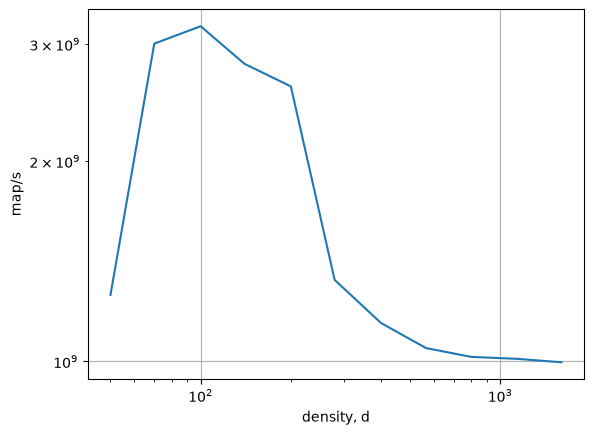

In [17]:
bruteforce_noswap = pd.read_csv("./bruteforce_serial_noswap.csv")
fig, ax = plt.subplots()
ax.plot(bruteforce_noswap['d'], bruteforce_noswap['map/s'])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('density, d')
ax.set_ylabel('map/s')
ax.grid();

Theoretically, our arithmetic intensity should be incredibly high.
- We do 1000 iterations for each point, each iteration is 7 FLOPs
- This should be a theoretical FLOP/byte of
$$ \frac{7000 FLOP}{16 byte} \approx 437$$
- But we're still clearly in memory-bound computation

Why?

**Loop ordering**

- Arithmetic intensity is not about the total bytes and total FLOPs
- **It is the FLOPs you execute while the data is in registers/L1 cache**

- By looping over iterations first, we're actually moving the point data `m` times.
    - Thus, our actual arithmetic intensity is
$$\frac{7 FLOP}{16 byte} \approx 0.4375$$

If we change the loop order to have iterations inside:


```c
  // iterate over map
  for (long indA = 0; indA < numA; ++indA) {
    for (long indB = 0; indB < numB; ++indB) {
      // apply function to each grid point
      for (long indf = 0; indf < args.max_iter; ++indf) {
        long indAB = indA * numB + indB;
        double scratch = MMAP_REAL(A[indAB], B[indAB], A_0[indA]);
        B[indAB] = MMAP_IMAG(A[indAB], B[indAB], B_0[indB]);
        A[indAB] = scratch;
      }
    }
  }
```

Now we get

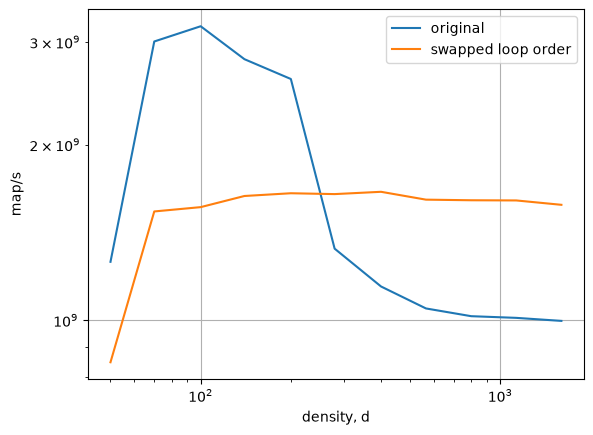

In [18]:
bruteforce_swap = pd.read_csv("./bruteforce_serial_swap.csv")
fig, ax = plt.subplots()

ax.plot(bruteforce_noswap['d'], bruteforce_noswap['map/s'], label='original')
ax.plot(bruteforce_swap['d'], bruteforce_swap['map/s'], label='swapped loop order')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('density, d')
ax.set_ylabel('map/s')
ax.grid()
ax.legend();

- The performance is (nearly) constant (excluding the smallest density
    - Thus, we are in the compute-bound regime now!
    - Our actual arithmetic intensity is the "real" 423 FLOPs/byte

**Why is the original faster at smaller densities though?**

## How would we figure this out?

We can use `perf` to figure out what is happening, focusing on Top-down Microarchitecture Analysis (TMA)
- TMA is a way of categorizing what is preventing the CPU from going faster
- It puts the time the CPU is spending into a hierarchy of categories
- Originally introduced in [*A Top-Down method for performance analysis and counters architecture*](https://doi-org.colorado.idm.oclc.org/10.1109/ISPASS.2014.6844459)

Here is the top-most level hierarchy:

| Level | Meaning |
| --- | --- |
| Retiring | This represents cycles spent on instructions that were successfully completed. This is the ideal case. |
| Frontend Bound | This represents stalls occurring because the CPU cannot fetch or decode instructions fast enough to keep the backend busy. |
| Backend Bound | This represents stalls occurring because the execution units are busy or waiting for data (e.g., memory latency or bandwidth issues). |
| Bad Speculation | This represents work wasted on instructions that were executed but eventually discarded due to branch mispredictions or other pipeline flushes. |

![TMA Diagram](https://yukunj.github.io/images/blogs/tma.png)

Blog: https://yukunj.github.io/blogs/tma

### Using `perf` for TMA

Start by running the program with
```
perf stat <program>
```
For example:
```
$ perf stat ./mandelbrot_bruteforce_blocked -d 100 > /dev/null
[...]
Performance counter stats for './mandelbrot_bruteforce_blocked -d 100':

                 1      context-switches                 #      4.9 cs/sec  cs_per_second
                 0      cpu-migrations                   #      0.0 migrations/sec  migrations_per_second
               382      page-faults                      #   1855.4 faults/sec  page_faults_per_second
            205.89 msec task-clock                       #      nan CPUs  CPUs_utilized
            14,592      branch-misses                    #      0.0 %  branch_miss_rate
       104,569,656      branches                         #    507.9 M/sec  branch_frequency
       840,910,525      cpu-cycles                       #      4.1 GHz  cycles_frequency
     1,639,739,158      instructions                     #      1.9 instructions  insn_per_cycle
            TopdownL1 #     47.5 %  tma_backend_bound
                                                         #      0.8 %  tma_bad_speculation
                                                         #      8.6 %  tma_frontend_bound
                                                         #     43.1 %  tma_retiring
```

The `# <number> % tma_*` gives information about the time spent by the CPU in each category.

To drill further, we can run 

```
perf stat -M tma_*_group <program>
```

where the `*` gets replaced by whatever specific group you want to know information about.
This allows us to do deeper into the hierarchy.


<div class="alert alert-block alert-info">
<b></b> 
If you want more information about a specific group or what it means, search for it in `perf list -v`.
</div>

Drilling down, we end up looking at port utilization
- `tma_ports_utilized_*` indicates the percent of the time where the CPU cores were doing 0, 1, 2 or 3 $\mu$ops
    - The more $\mu$ops we do at once, the faster we perform our computations

**Normal Bruteforce:**
```
$ sudo perf stat -M tma_ports_utilization_group ./mandelbrot_bruteforce -d 100 > /dev/null
[....]
       665,182,876      TOPDOWN.SLOTS                    #      0.2 %  tma_ports_utilized_0
                                                         #     12.5 %  tma_ports_utilized_1
                                                         #     18.6 %  tma_ports_utilized_2     (88.73%)
        81,736,062      UOPS_EXECUTED.CYCLES_GE_3        #     60.4 %  tma_ports_utilized_3m    (88.72%)
```

**Swapped Bruteforce:**
```
$ sudo perf stat -M tma_ports_utilization_group ./mandelbrot_bruteforce_swap -d 100 > /dev/null
[....]
     1,173,759,662      TOPDOWN.SLOTS                    #     34.3 %  tma_ports_utilized_0
                                                         #     43.3 %  tma_ports_utilized_1
                                                         #      8.9 %  tma_ports_utilized_2     (89.97%)
        25,922,080      UOPS_EXECUTED.CYCLES_GE_3        #     11.0 %  tma_ports_utilized_3m    (89.99%)
```


Normal bruteforce gets better ILP!

- By having the outer loop over iterations, each inner loop is completely independent!
    - Thus, the CPU can dispatch every instruction in that loop independently of the next
    
```c
  for (long indf = 0; indf < args.max_iter; ++indf) {
    for (long indA = 0; indA < numA; ++indA) {
      for (long indB = 0; indB < numB; ++indB) {
        long indAB = indA * numB + indB;
        double scratch = MMAP_REAL(A[indAB], B[indAB], A_0[indA]);
        B[indAB] = MMAP_IMAG(A[indAB], B[indAB], B_0[indB]);
        A[indAB] = scratch;
      }
    }
  }
```

## Blocked

What if we combined the two stratgies?
- Ensure the inner-most loop has independent data
- Ensure that computations are done while required data are located in cache

This is sometimes known as **blocking**.
- We divide the data to be computed on into blocks
- Then we operate on those blocks while the data is in cache

 The easiest way for us to do that is simply put the iteration loop between our row loop and our column loop:
```c
  for (long indA = 0; indA < numA; ++indA) {
    for (long indf = 0; indf < args.max_iter; ++indf) {
      for (long indB = 0; indB < numB; ++indB) {
        long indAB = indA * numB + indB;
        double scratch = MMAP_REAL(A[indAB], B[indAB], A_0[indA]);
        B[indAB] = MMAP_IMAG(A[indAB], B[indAB], B_0[indB]);
        A[indAB] = scratch;
      }
    }
  }
```

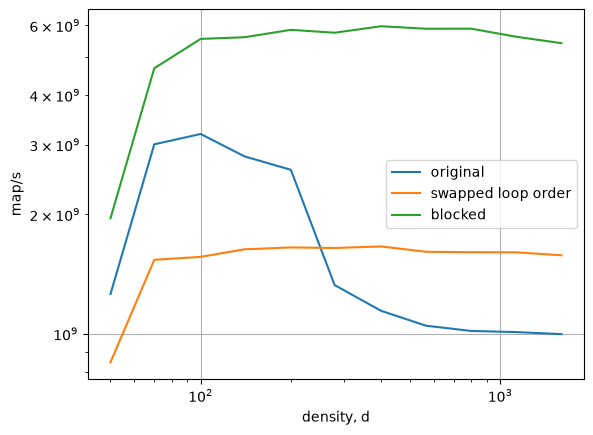

In [19]:
bruteforce_blocked = pd.read_csv("./bruteforce_serial_blocked.csv")
fig, ax = plt.subplots()

ax.plot(bruteforce_noswap['d'], bruteforce_noswap['map/s'], label='original')
ax.plot(bruteforce_swap['d'], bruteforce_swap['map/s'], label='swapped loop order')
ax.plot(bruteforce_blocked['d'], bruteforce_blocked['map/s'], label='blocked')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('density, d')
ax.set_ylabel('map/s')
ax.grid()
ax.legend();

We get the best of both worlds!
- We get the best performance at small densities
- We get the best performance at large densities
- The performance is completely independent of the computation being done!

### Different form of blocked

What if we wanted to block by some arbitrary amount rather than by rows?
- For instance, maybe the size of each row exceeds L1 cache

Could we instead

```c
#define BLOCK_SIZE 80000
  // iterate over map
  for (long block = 0; block < numA * numB / BLOCK_SIZE; ++block) {
    long indAB_start = block * BLOCK_SIZE;
    long indAB_stop = (block + 1) * BLOCK_SIZE;
    if (indAB_stop > numA * numB)
      indAB_stop = numA * numB;
    for (long indf = 0; indf < max_iter; ++indf) {
      for (long indAB = indAB_start; indAB < indAB_stop; ++indAB) {

        long indA = indAB / numB;
        long indB = indAB % numB;
        double scratch = MMAP_REAL(A[indAB], B[indAB], A_0[indA]);
        B[indAB] = MMAP_IMAG(A[indAB], B[indAB], B_0[indB]);
        A[indAB] = scratch;
      }
    }
  }
```

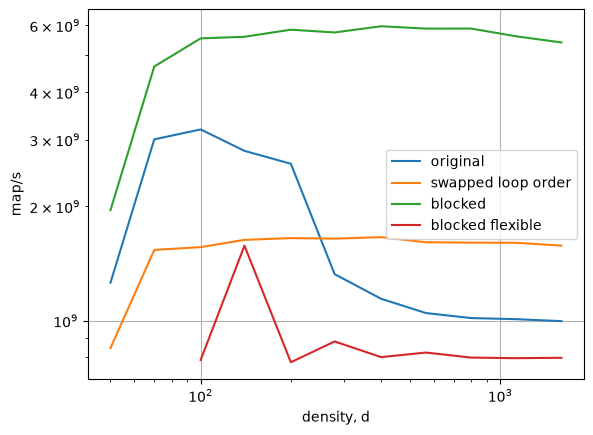

In [21]:
bruteforce_blocked_flex = pd.read_csv("./bruteforce_serial_blocked_flex.csv")
fig, ax = plt.subplots()

ax.plot(bruteforce_noswap['d'], bruteforce_noswap['map/s'], label='original')
ax.plot(bruteforce_swap['d'], bruteforce_swap['map/s'], label='swapped loop order')
ax.plot(bruteforce_blocked['d'], bruteforce_blocked['map/s'], label='blocked')
ax.plot(bruteforce_blocked_flex['d'][2:], bruteforce_blocked_flex['map/s'][2:], label='blocked flexible')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('density, d')
ax.set_ylabel('map/s')
ax.grid()
ax.legend();

Why are we getting so much lower?

Back to perf!

### `perf record`

This allows us to get a much closer examination into exactly where in the code time is being taken.
Two set process:
1. Record the execution of the event
2. Examine the resulting data

To record simply

```
perf record <program>
```

This outputs a `perf.data` file

Then, to examine, we use `perf report`.
- This automatically looks for a `perf.data` file and reads that out

**Annotate Assembly**
- Perf can tell use exactly which instructions spent the most time executing
    - Use `<Tab>` and `<Shift> + <Tab>` to go between the longest running instructions
- Jump instructions also annotated

**Vector Instructions vs Scalar Instructions**
- `*sd` instructions means "scalar double" instructions, indicating lack of vectorization.
- `*pd` "packed double" instructions, which are vectorized instructions

### Vectorization fails

- We see that the flexible version of blocked fails to vectorize the inner loop
    - Most time spent in `*sd` instructions
    - While the row-based blocking spends it's time in the `*pd` instructions
- Even with `#pragma omp simd`, still don't get vectorization
- Some possible reasons (in order from most likely to least likely, in my opinion)
    - Can't follow the memory access pattern (with the integer division and modulo operator)
        - Previously the `long indAB = indA * numB + indB;` indexing was done
        - This is a *very* common pattern (even if not done explicitly by the programmer), so the compiler can pick up on what the intention is
        - By comparison, doing the integer division/modulo is not very common and is a bit more obtuse
    - Integer division/modulo is slow, which means the compiler doesn't see value in vectorization
    - Attempts and fails to vectorize the integer division and modulo operators